In [1]:
import numpy as np
import matplotlib.pyplot as plt
from ipywidgets import FloatSlider, interactive
from scipy.optimize import root_scalar
from matplotlib.animation import FuncAnimation
from IPython.display import display
from matplotlib.patches import Polygon

blocked_light = 0.90

def fresnel_vgl(theta_i_graden, n1, n2):
    theta_i = np.radians(theta_i_graden)
    sin_t = (n1/n2) * np.sin(theta_i)
    
    if sin_t > 1: # als onmogelijke brekingshoek -> die waarde overslaan
        return None
    
    theta_t = np.arcsin(sin_t)
    
    Rs = ((n1*np.cos(theta_i) - n2*np.cos(theta_t))/(n1*np.cos(theta_i) + n2*np.cos(theta_t)))**2
    Rp = ((n2*np.cos(theta_i) - n1*np.cos(theta_t))/(n2*np.cos(theta_i) + n1*np.cos(theta_t)))**2
    
    return Rp / (Rs + Rp)

def bepaling_grenzen(n1, n2):
    thetas = np.linspace(0.1, 89.9, 50000)
    values = np.array([fresnel_vgl(t, n1, n2) for t in thetas])
    
    mask = values <= 1-blocked_light # eis van 80%
    
    return float(thetas[mask][0]), float(thetas[mask][-1]) # geeft de minimale hoek en de maximale hoek die voldoet aan de eis

def brewster_hoek(n1, n2):
    return np.degrees(np.arctan(n2/n1))

min_hoek_w, max_hoek_w = bepaling_grenzen(1.0, 1.33)
min_hoek_g, max_hoek_g = bepaling_grenzen(1.0, 1.49)
ideale_hoek_w = brewster_hoek(1.0, 1.33)
ideale_hoek_g = brewster_hoek(1.0, 1.49)

print("Range van mogelijke invalshoeken van het licht voor de gestelde eis voor reflectieoppervlak;")
print(f"  -   Water: [{min_hoek_w:.2f}°, {max_hoek_w:.2f}°]")
print(f"  -   Plexiglas: [{min_hoek_g:.2f}°, {max_hoek_g:.2f}°]")
print("ideale invalshoek van het licht voor de gestelde eis voor reflectieoppervlak;")
print(f"  -   Water: {ideale_hoek_w:.2f}°")
print(f"  -   Plexiglas: {ideale_hoek_g:.2f}°")

Range van mogelijke invalshoeken van het licht voor de gestelde eis voor reflectieoppervlak;
  -   Water: [41.23°, 65.03°]
  -   Plexiglas: [43.70°, 68.26°]
ideale invalshoek van het licht voor de gestelde eis voor reflectieoppervlak;
  -   Water: 53.06°
  -   Plexiglas: 56.13°


interactive(children=(FloatSlider(value=0.0, description='xt', max=0.5, step=0.01), FloatSlider(value=0.0, des…

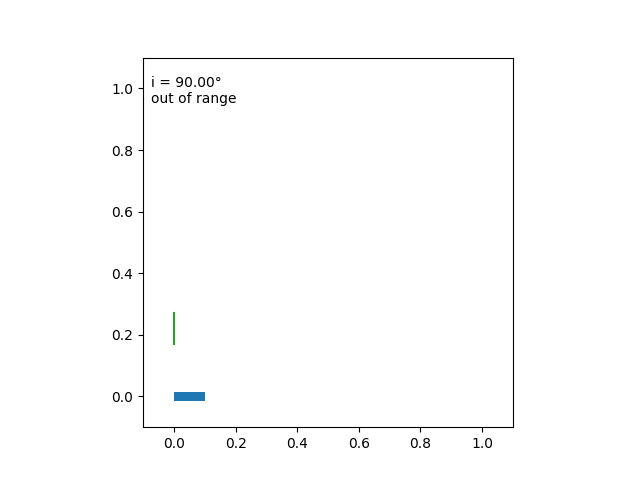

In [2]:
%matplotlib widget

hoogte_opstelling = 0.22
extra_ruimte = 0.1
torch_beam_angle = np.radians(2)

lens_pos = np.array([0, hoogte_opstelling])
mirror_size = 0.20
lens_size = 0.10
torch_w = 0.03
torch_h = 0.10

def compute_corners(pos, w, h, angle):
    a = pos+np.array([0.5*w*np.sin(angle), -0.5*w*np.cos(angle)])
    b = pos+np.array([-0.5*w*np.sin(angle), 0.5*w*np.cos(angle)])
    c = pos+np.array([-0.5*w*np.sin(angle), 0.5*w*np.cos(angle)])+np.array([h*np.cos(angle), h*np.sin(angle)])
    d = pos+np.array([0.5*w*np.sin(angle), -0.5*w*np.cos(angle)])+np.array([h*np.cos(angle), h*np.sin(angle)])
    return np.array([a, b, c, d])

def intersect_horizontal(a, alpha, b):
    xA, yA = a
    x = xA + (b - yA) / np.tan(alpha)
    return x

def in_range(i, i_min, i_max):
    return i_min <= i <= i_max

xt = 1
yt = 1
at = 20

torch_pos = np.array([xt, yt])
torch_angle = np.radians(at)

i = 0.5*(np.pi-torch_angle)
am = 0.5*np.pi-i
xm = intersect_horizontal(torch_pos, torch_angle, hoogte_opstelling)

mirror_pos = np.array([xm, hoogte_opstelling])

#figure
fig, ax = plt.subplots()
info_text = ax.text(0.02, 0.95, "", transform=ax.transAxes, va="top")
ax.set_aspect('equal')

#limits
ax.set_xlim(lens_pos[0]-extra_ruimte, max(torch_pos[0], mirror_pos[0])+extra_ruimte)
ax.set_ylim(0-extra_ruimte, max(mirror_pos[1], torch_pos[1])+extra_ruimte)

#line
line1, = ax.plot(np.array([lens_pos[0], mirror_pos[0]]), np.array([lens_pos[1], mirror_pos[1]]))
line2, = ax.plot(np.array([mirror_pos[0], torch_pos[0]]), np.array([mirror_pos[1], torch_pos[1]]))
lens, = ax.plot(np.full(1000, lens_pos[0]), np.linspace(lens_pos[1]-0.5*lens_size, lens_pos[1]+0.5*lens_size, 1000))

mirror, = ax.plot(
    np.linspace(mirror_pos[0]-0.5*mirror_size*np.cos(am), mirror_pos[0]+0.5*mirror_size*np.cos(am), 1000), 
    np.linspace(mirror_pos[1]-0.5*mirror_size*np.sin(am), mirror_pos[1]+0.5*mirror_size*np.sin(am), 1000))

corners = compute_corners(torch_pos, torch_w, torch_h, torch_angle)
rect = Polygon(corners, closed=True)
ax.add_patch(rect)


#animation
def update(xt=1, yt = 1, at = 0):
    
    torch_pos = np.array([xt, yt])
    torch_angle = np.radians(at)

    i = 0.5*(np.pi-torch_angle)
    am = 0.5*np.pi-i
    xm = intersect_horizontal(torch_pos, torch_angle, hoogte_opstelling)

    mirror_pos = np.array([xm, hoogte_opstelling])

    x1 = np.array([lens_pos[0], mirror_pos[0]])
    y1 = np.array([lens_pos[1], mirror_pos[1]])
    x2 = np.array([mirror_pos[0], torch_pos[0]])
    y2 = np.array([mirror_pos[1], torch_pos[1]])
    x3 = np.full(1000, lens_pos[0])
    y3 = np.linspace(lens_pos[1]-0.5*lens_size, lens_pos[1]+0.5*lens_size, 1000)
    x4 = np.linspace(mirror_pos[0]-0.5*mirror_size*np.cos(am), mirror_pos[0]+0.5*mirror_size*np.cos(am), 1000)
    y4 = np.linspace(mirror_pos[1]-0.5*mirror_size*np.sin(am), mirror_pos[1]+0.5*mirror_size*np.sin(am), 1000)

    #set the line
    line1.set_data(x1, y1)
    line2.set_data(x2, y2)
    lens.set_data(x3, y3)
    mirror.set_data(x4, y4)
    
    corners = compute_corners(torch_pos, torch_w, torch_h, torch_angle)
    rect.set_xy(corners)

    #draw the line
    fig.canvas.draw_idle()

    if in_range(np.degrees(i), min_hoek_g, max_hoek_g):
        status = "in range"
    else:
        status = "out of range"
    info_text.set_text(f"i = {np.degrees(i):.2f}°\n{status}")

#create slider
slider1 = FloatSlider(value=0, min=0, max=0.50, step=0.01)
slider2 = FloatSlider(value=0, min=0, max=0.50, step=0.01)
slider3 = FloatSlider(value=0, min=0, max=180, step=0.01)
ui = interactive(update, xt=slider1, yt = slider2, at = slider3)
display(ui)